In [ ]:
# Install SHAP and import libraries
!pip install shap -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import load_model, Model
import xgboost as xgb
import shap
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded")
print(f"SHAP version: {shap.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

Libraries loaded
SHAP version: 0.52.0
GPU available: True


In [ ]:
# Load the merged dataset
df = pd.read_csv('/content/final_dataset_2022_2024.csv', index_col=0)
df.index = pd.to_datetime(df.index, dayfirst=True)
df = df.sort_index()

print("Dataset loaded")
print(f"Rows: {df.shape[0]}")
print(f"From: {df.index.min().date()}")
print(f"To:   {df.index.max().date()}")

Dataset loaded
Rows: 52461
From: 2022-01-01
To:   2024-12-31


In [ ]:
# Load the trained LSTM and hybrid XGBoost models
lstm_model = load_model('/content/lstm_model.keras')

hybrid_model = xgb.XGBRegressor()
hybrid_model.load_model('/content/hybrid_model.json')

print("LSTM model loaded")
print("Hybrid XGBoost model loaded")

LSTM model loaded
Hybrid XGBoost model loaded


In [ ]:
# Define the feature set matching the LSTM's training input
feature_cols = [
    'demand_mw',
    'temp_c', 'wind_speed_kmh', 'humidity_pct',
    'precip_mm', 'wind_chill', 'temp_squared',
    'hour', 'day_of_week', 'month',
    'is_weekend', 'halfhour_slot',
    'event_flag', 'event_intensity',
    'is_public_holiday',
    'hour_sin', 'hour_cos',
    'dow_sin', 'dow_cos',
    'month_sin', 'month_cos'
]

data = df[feature_cols].dropna()

train_data = data[data.index.year.isin([2022, 2023])]
test_data  = data[data.index.year == 2024]

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_data)
test_scaled  = scaler.transform(test_data)

SEQ_LEN = 48

def create_sequences(data, sequence_length=48):
    X = []
    y = []
    for i in range(sequence_length, len(data)):
        X.append(data[i - sequence_length:i])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X_test_seq, y_test = create_sequences(test_scaled, SEQ_LEN)

_ = lstm_model.predict(X_test_seq[:1], verbose=0)

embedding_model = Model(
    inputs  = lstm_model.inputs,
    outputs = lstm_model.layers[-3].output
)

test_embeddings = embedding_model.predict(X_test_seq, verbose=0)

print(f"Test embeddings shape: {test_embeddings.shape}")
print("LSTM embeddings extracted")

Test embeddings shape: (17402, 32)
LSTM embeddings extracted


In [ ]:
# Define the structured feature set used by the hybrid model
xgb_feature_cols = [
    'temp_c', 'wind_speed_kmh', 'humidity_pct',
    'precip_mm', 'wind_chill', 'temp_squared',
    'hour', 'day_of_week', 'month',
    'is_weekend', 'halfhour_slot',
    'event_flag', 'event_intensity',
    'is_public_holiday',
    'hour_sin', 'hour_cos',
    'dow_sin', 'dow_cos',
    'month_sin', 'month_cos',
    'demand_lag_24h', 'demand_lag_168h',
    'demand_rolling_24h_mean'
]

test_structured = df[xgb_feature_cols].loc[test_data.index[SEQ_LEN:]].values

X_test_hybrid = np.hstack([test_embeddings, test_structured])

embedding_names = [f'lstm_{i}' for i in range(test_embeddings.shape[1])]
all_feature_names = embedding_names + xgb_feature_cols

X_test_named = pd.DataFrame(X_test_hybrid, columns=all_feature_names)

print(f"Hybrid input shape: {X_test_named.shape}")
print(f"Total features: {len(all_feature_names)}")
print(f"LSTM embedding features: {len(embedding_names)}")
print(f"Structured features: {len(xgb_feature_cols)}")

Hybrid input shape: (17402, 55)
Total features: 55
LSTM embedding features: 32
Structured features: 23


In [ ]:
# Compute SHAP values on a 2,000-row sample of the test set
explainer = shap.TreeExplainer(hybrid_model)

sample_size = 2000
np.random.seed(42)
sample_idx = np.random.choice(len(X_test_named), sample_size, replace=False)
X_sample = X_test_named.iloc[sample_idx]

shap_values = explainer.shap_values(X_sample)

print(f"SHAP values computed for {sample_size} predictions")
print(f"SHAP values shape: {shap_values.shape}")

SHAP values computed for 2000 predictions
SHAP values shape: (2000, 55)


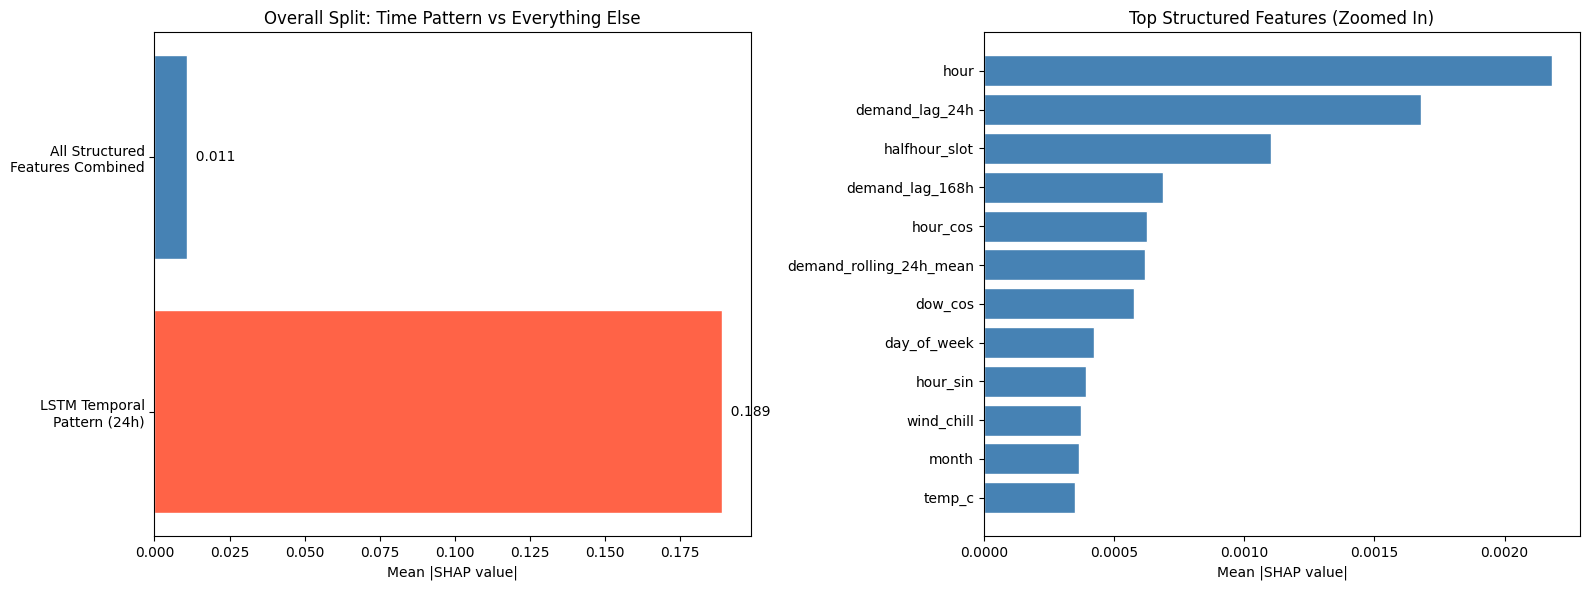

LSTM temporal pattern share: 94.5999984741211%
Structured features share: 5.400000095367432%
Top structured feature: hour


In [ ]:
# Split SHAP importance into LSTM embedding vs structured features
embedding_positions = [all_feature_names.index(f) for f in embedding_names]
structured_positions = [all_feature_names.index(f) for f in xgb_feature_cols]

lstm_group_importance = np.abs(shap_values[:, embedding_positions]).mean(axis=0).sum()
structured_importance = np.abs(shap_values[:, structured_positions]).mean(axis=0)
structured_total = structured_importance.sum()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(['LSTM Temporal\nPattern (24h)', 'All Structured\nFeatures Combined'],
             [lstm_group_importance, structured_total],
             color=['tomato', 'steelblue'], edgecolor='white')
axes[0].set_xlabel('Mean |SHAP value|')
axes[0].set_title('Overall Split: Time Pattern vs Everything Else')
for i, v in enumerate([lstm_group_importance, structured_total]):
    axes[0].text(v, i, f'  {v:.3f}', va='center')

top_n = 12
order = np.argsort(structured_importance)[::-1][:top_n]
names_sorted = [xgb_feature_cols[i] for i in order]
values_sorted = [structured_importance[i] for i in order]

axes[1].barh(names_sorted[::-1], values_sorted[::-1], color='steelblue', edgecolor='white')
axes[1].set_xlabel('Mean |SHAP value|')
axes[1].set_title('Top Structured Features (Zoomed In)')

plt.tight_layout()
plt.savefig('/content/step6_chart1_shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

lstm_share = 100 * lstm_group_importance / (lstm_group_importance + structured_total)
structured_share = 100 * structured_total / (lstm_group_importance + structured_total)
print(f"LSTM temporal pattern share: {round(lstm_share, 1)}%")
print(f"Structured features share: {round(structured_share, 1)}%")
print(f"Top structured feature: {names_sorted[0]}")

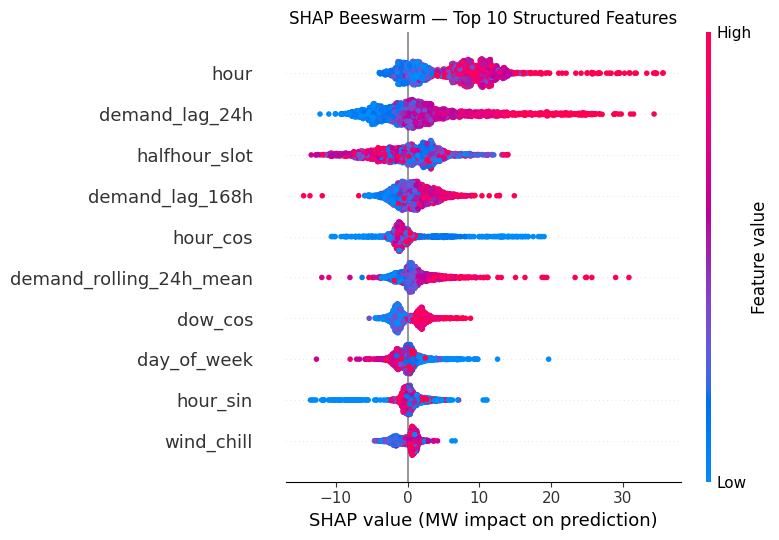

Top structured feature: hour
Features shown: ['hour', 'demand_lag_24h', 'halfhour_slot', 'demand_lag_168h', 'hour_cos', 'demand_rolling_24h_mean', 'dow_cos', 'day_of_week', 'hour_sin', 'wind_chill']


In [ ]:
# Convert top structured-feature SHAP values to MW and plot beeswarm
demand_min = scaler.data_min_[0]
demand_max = scaler.data_max_[0]
demand_range = demand_max - demand_min

top_n = 10
order = np.argsort(structured_importance)[::-1][:top_n]
top_names = [xgb_feature_cols[i] for i in order]
top_positions = [structured_positions[i] for i in order]

X_sample_top = X_sample[top_names]
shap_values_top_mw = shap_values[:, top_positions] * demand_range

plt.figure()
shap.summary_plot(shap_values_top_mw, X_sample_top,
                  max_display=10, show=False)
plt.xlabel('SHAP value (MW impact on prediction)')
plt.title('SHAP Beeswarm — Top 10 Structured Features')
plt.tight_layout()
plt.savefig('/content/step6_chart2_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Top structured feature: {top_names[0]}")
print(f"Features shown: {top_names}")

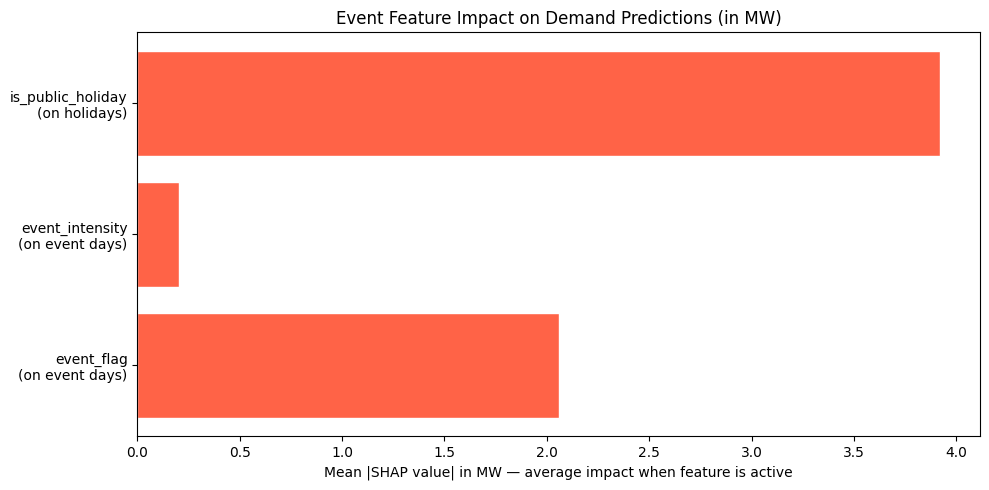

Event flag impact on event days:        2.06 MW
Event intensity impact on event days:   0.2 MW
Holiday flag impact on holidays:         3.92 MW

Sample sizes — event rows: 118, holiday rows: 62


In [ ]:
# Compute mean SHAP impact of event/holiday features in MW
demand_min = scaler.data_min_[0]
demand_max = scaler.data_max_[0]
demand_range = demand_max - demand_min

event_mask   = X_sample['event_flag'].values == 1
holiday_mask = X_sample['is_public_holiday'].values == 1

event_flag_mw = np.abs(shap_values[event_mask][:, all_feature_names.index('event_flag')]).mean() * demand_range
event_int_mw  = np.abs(shap_values[event_mask][:, all_feature_names.index('event_intensity')]).mean() * demand_range
holiday_mw    = np.abs(shap_values[holiday_mask][:, all_feature_names.index('is_public_holiday')]).mean() * demand_range

labels = ['event_flag\n(on event days)',
          'event_intensity\n(on event days)',
          'is_public_holiday\n(on holidays)']
values = [event_flag_mw, event_int_mw, holiday_mw]

plt.figure(figsize=(10, 5))
plt.barh(labels, values, color='tomato', edgecolor='white')
plt.title('Event Feature Impact on Demand Predictions (in MW)')
plt.xlabel('Mean |SHAP value| in MW — average impact when feature is active')
plt.tight_layout()
plt.savefig('/content/step6_chart3_event_features.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Event flag impact on event days:        {round(float(event_flag_mw), 2)} MW")
print(f"Event intensity impact on event days:   {round(float(event_int_mw), 2)} MW")
print(f"Holiday flag impact on holidays:         {round(float(holiday_mw), 2)} MW")
print(f"\nSample sizes — event rows: {event_mask.sum()}, holiday rows: {holiday_mask.sum()}")

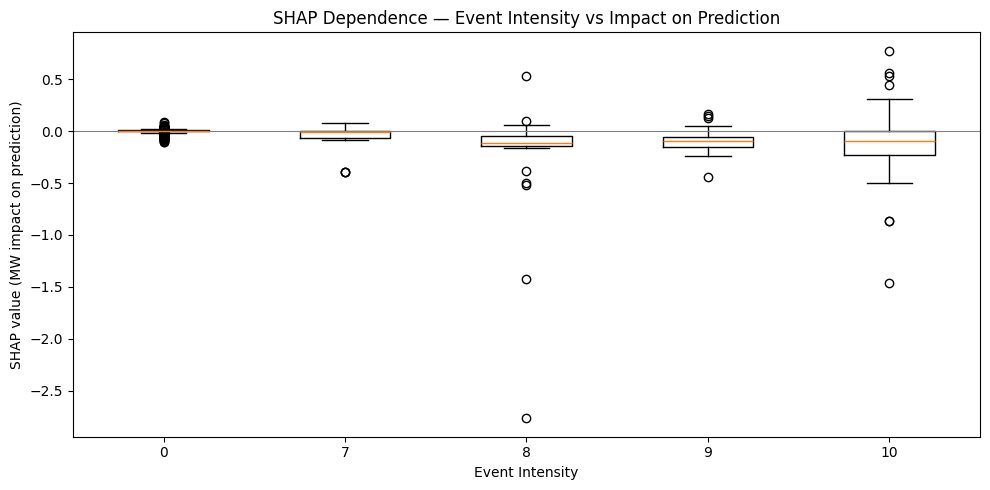

Intensity 0: mean impact 0.0 MW, n=1882
Intensity 7: mean impact -0.08 MW, n=18
Intensity 8: mean impact -0.21 MW, n=32
Intensity 9: mean impact -0.08 MW, n=29
Intensity 10: mean impact -0.12 MW, n=39


In [ ]:
# Plot SHAP dependence of event_intensity on prediction
event_intensity_shap_mw = shap_values[:, all_feature_names.index('event_intensity')] * demand_range

plt.figure(figsize=(10, 5))
levels = sorted(X_sample['event_intensity'].unique())
data_by_level = [event_intensity_shap_mw[X_sample['event_intensity'].values == lvl] for lvl in levels]
plt.boxplot(data_by_level, labels=[str(int(l)) for l in levels])
plt.axhline(0, color='grey', linewidth=0.8)
plt.xlabel('Event Intensity')
plt.ylabel('SHAP value (MW impact on prediction)')
plt.title('SHAP Dependence — Event Intensity vs Impact on Prediction')
plt.tight_layout()
plt.savefig('/content/step6_chart4_event_intensity_dependence.png', dpi=150, bbox_inches='tight')
plt.show()

for lvl, vals in zip(levels, data_by_level):
    print(f"Intensity {int(lvl)}: mean impact {round(float(np.mean(vals)), 2)} MW, n={len(vals)}")

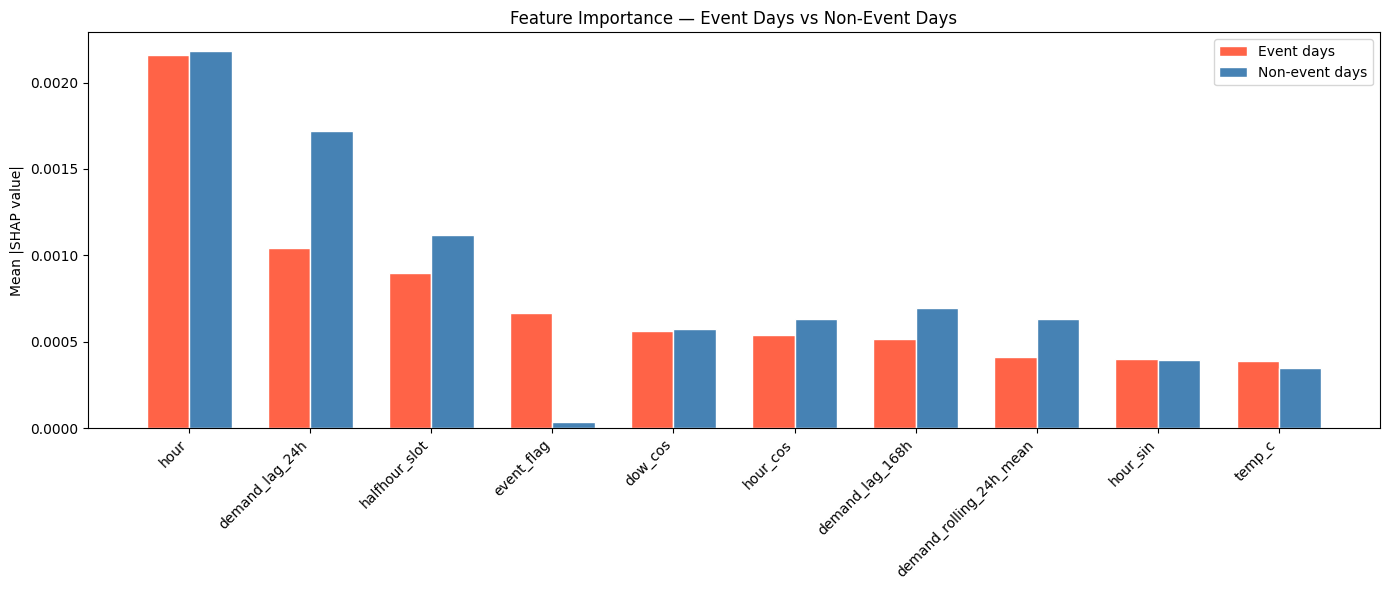

Event day predictions in sample: 118
Non-event day predictions in sample: 1882


In [ ]:
# Compare structured feature importance on event vs non-event days
event_flag_position = all_feature_names.index('event_flag')
event_mask = X_sample['event_flag'].values == 1

shap_event    = np.abs(shap_values[event_mask]).mean(axis=0)
shap_nonevent = np.abs(shap_values[~event_mask]).mean(axis=0)

structured_shap_event    = shap_event[structured_positions]
structured_shap_nonevent = shap_nonevent[structured_positions]

top10_idx = np.argsort(structured_shap_event)[::-1][:10]
top10_names = [xgb_feature_cols[i] for i in top10_idx]

x = np.arange(10)
width = 0.35

plt.figure(figsize=(14, 6))
plt.bar(x - width/2, structured_shap_event[top10_idx],    width, label='Event days',     color='tomato',    edgecolor='white')
plt.bar(x + width/2, structured_shap_nonevent[top10_idx], width, label='Non-event days', color='steelblue', edgecolor='white')
plt.xticks(x, top10_names, rotation=45, ha='right')
plt.ylabel('Mean |SHAP value|')
plt.title('Feature Importance — Event Days vs Non-Event Days')
plt.legend()
plt.tight_layout()
plt.savefig('/content/step6_chart5_event_vs_nonevent_shap.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Event day predictions in sample: {event_mask.sum()}")
print(f"Non-event day predictions in sample: {(~event_mask).sum()}")